# Time-Based Corrosion Analysis: Effect of Exposure Time on Corrosion Rate and Inhibition Efficiency
### Final Year Project - Time Series Analysis
**Department of Chemical Engineering**

**Federal University of Petroleum Resources, Effurun (FUPRE)**

**Student: TEBEREN JOSEPH – CHE/18/XXXX**

**Supervisor: [Supervisor’s Name]**
S
**2024/2025 Session**

## 1. Project Overview

This analysis focuses on the **time-dependent behavior** of corrosion inhibition in HCl solutions. Using the **weight loss technique**, we investigate how **exposure time** (3h, 6h, 9h, 12h, 15h) affects **corrosion rate** and **inhibition efficiency** at **room temperature**.

**Core Objectives**:
- Quantify **corrosion rate (mm/year)** and **inhibition efficiency (%)** over time.
- Analyze effects of **acid strength** and **exposure duration** on inhibitor performance.
- Apply **Exploratory Data Analysis (EDA)** to identify optimal exposure times.
- Build **machine learning models** to predict:
  - **Corrosion rate** from `acid_m`, `conc_ppm`, `time_h`
  - **Inhibition efficiency** from same inputs
- Deliver **practical engineering guidelines** for time-based corrosion control.

## 2. Experimental Method – Weight Loss Technique

The **classical weight loss method** (ASTM G31) was employed at **room temperature** to study time-dependent corrosion behavior.

**Procedure**:
1. Mild steel coupons polished, cleaned, and weighed (**initial_weight_g**).
2. Immersed in **0.5M, 1.0M, 1.5M HCl** with/without inhibitor at **room temperature**.
3. **Exposure time**: 3h, 6h, 9h, 12h, 15h.
4. Coupons retrieved, cleaned (ASTM G1), dried, re-weighed (**final_weight_g**).
5. **Weight loss (mg)** → **Corrosion rate (mm/year)** → **Inhibition efficiency (%)**.

**Inhibitor**: Dosed at **50, 150, 250, 350, 450 ppm** + **Control (0 ppm)**.

## 3. Dataset Structure & Column Descriptions

The time-based dataset contains **9 columns** and **75 experimental runs**:

| Column | Unit | Description |
|--------|------|-------------|
| **`acid_m`** | M | HCl molarity: `0.5, 1.0, 1.5` |
| **`time_h`** | hours | Immersion duration: `3, 6, 9, 12, 15` |
| **`conc_ppm`** | ppm | Inhibitor concentration: `0 (Control), 50, 150, 250, 350, 450` |
| **`initial_weight_g`** | g | Coupon mass before test |
| **`final_weight_g`** | g | Coupon mass after test |
| **`wl_g`** | g | `initial − final` |
| **`wl_mg`** | mg | `wl_g × 1000` – input to CR formula |
| **`ie_percent`** | % | $$\eta (\%) = \frac{W_{\text{blank}} - W_{\text{inhib}}}{W_{\text{blank}}} \times 100$$ |
| **`cr_mm_yr`** | mm/year | $$CR = \frac{87.6 \times W}{D \times A \times T}$$ <br> $W$ = mg, $D$ = 7.85 g/cm³, $A$ = cm², $T$ = hours |

> **Total Conditions**: 3 acids × 5 times × 6 doses (incl. control) = **90 possible**, but **75 runs** from time series data.

## 4. Why This Analysis Matters

- **Time-dependent corrosion** is critical for **process safety** and **equipment lifespan**.
- **Short-term vs long-term** inhibitor performance assessment.
- **Economic optimization**: Balance between **exposure time** and **corrosion control**.
- **ML prediction** enables:
  - **Time-based maintenance scheduling**
  - **Process optimization** for batch operations
  - **Risk assessment** for extended exposures

## 5. Analysis Execution Plan

1. **Data Preprocessing**  
   - Replace `"Control"` → `0` in `conc_ppm`  
   - Fill `ie_percent = 0` for control  
   - Validate CR and IE formulas

2. **Exploratory Data Analysis (EDA) – 15 Key Questions**  
   - Q1: How does CR change with exposure time?  
   - Q2: Is corrosion rate linear with time?  
   - Q3: Which time gives lowest CR for each acid?  
   - Q4: Does IE degrade over time?  
   - Q5: Best inhibitor concentration for 15h exposure?  
   - Q6: Time trend for blank corrosion  
   - Q7: Critical exposure time (CR > 10 mm/year)?  
   - Q8: Minimum PPM for safe 12h exposure?  
   - Q9: Time consistency of IE across acids  
   - Q10: IE vs time – kinetic modeling  
   - Q11: 3D surface: CR vs PPM × Time  
   - Q12: Heatmap: IE across time × acid grid  
   - Q13: Time series plots for each condition  
   - Q14: Boxplot: CR distribution per time  
   - Q15: Safe operating window (time vs dose)

3. **Feature Engineering**  
   - `log_ppm`, `ppm²`, `1/(ppm+1)`  
   - `time_h²`, `1/time_h`  
   - `acid_m × time_h`, `ppm × time_h`  
   - StandardScaler for ML

4. **Statistical Analysis**  
   - Correlation matrix + heatmap  
   - Time-corrosion relationships  
   - PPM effectiveness over time

5. **Machine Learning Models**  

| Model | Target | Purpose |
|-------|--------|---------|
| Ridge & CatBoost | CR, IE | Baseline |
| Random Forest | CR, IE | Feature importance |
| MLP Neural Net | CR, IE | Complex patterns |
| Polynomial (deg 2) | CR, IE | Non-linearity |

   - 5-fold CV  
   - Metrics: R², MAE, RMSE  

6. **Model Validation & Selection**  
   - Residual analysis  
   - Feature importance  
   - Model export

7. **Time-Based Deliverables**  
   - **Time Guidelines**: Max safe exposure per acid/dose  
   - **Process Optimization**: Time-dose recommendations  
   - **Risk Assessment**: Time-dependent corrosion prediction

8. **Conclusion & Impact**  
   - Time-dependent findings  
   - Process implications  
   - Future work

## 6. Implementation

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 8)

### 1. Data Preprocessing

In [2]:
# Load the time-based dataset
df = pd.read_csv('/content/sample_data/all_no_temp_cleaned.csv')
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Unique times:", sorted(df['time_h'].unique()))
df.head()

Dataset shape: (90, 9)
Columns: ['acid_m', 'time_h', 'conc_ppm', 'initial_weight_g', 'final_weight_g', 'wl_g', 'wl_mg', 'ie_percent', 'cr_mm_yr']
Unique times: [np.int64(3), np.int64(6), np.int64(9), np.int64(12), np.int64(15)]


,acid_m,time_h,conc_ppm,initial_weight_g,final_weight_g,wl_g,wl_mg,ie_percent,cr_mm_yr
0,0.5,3,50,6.810,6.625,0.185,185.0,26.3,40.3
1,0.5,3,150,6.206,6.058,0.148,148.0,41.0,32.2
2,0.5,3,250,5.854,5.753,0.101,101.0,59.8,22.0
3,0.5,3,350,6.264,6.240,0.024,24.0,90.4,5.2
4,0.5,3,450,7.210,7.199,0.011,11.0,95.6,2.4


In [3]:
# Replace 'Control' with 0 in conc_ppm
df['conc_ppm'] = df['conc_ppm'].replace('Control', 0)
df['conc_ppm'] = df['conc_ppm'].astype(float)

# Fill ie_percent = 0 for control (conc_ppm == 0)
df['ie_percent'] = df['ie_percent'].fillna(0)

print("After preprocessing:")
df.head()

After preprocessing:


,acid_m,time_h,conc_ppm,initial_weight_g,final_weight_g,wl_g,wl_mg,ie_percent,cr_mm_yr
0,0.5,3,50.0,6.810,6.625,0.185,185.0,26.3,40.3
1,0.5,3,150.0,6.206,6.058,0.148,148.0,41.0,32.2
2,0.5,3,250.0,5.854,5.753,0.101,101.0,59.8,22.0
3,0.5,3,350.0,6.264,6.240,0.024,24.0,90.4,5.2
4,0.5,3,450.0,7.210,7.199,0.011,11.0,95.6,2.4


In [4]:
# Check data distribution
print("Data summary:")
print(df.groupby(['acid_m', 'time_h']).size().reset_index(name='count'))
print("\nTotal runs:", len(df))

Data summary:
    acid_m  time_h  count
0      0.5       3      6
1      0.5       6      6
2      0.5       9      6
3      0.5      12      6
4      0.5      15      6
5      1.0       3      6
6      1.0       6      6
7      1.0       9      6
8      1.0      12      6
9      1.0      15      6
10     1.5       3      6
11     1.5       6      6
12     1.5       9      6
13     1.5      12      6
14     1.5      15      6

Total runs: 90


### 2. Exploratory Data Analysis (EDA) – 15 Key Questions

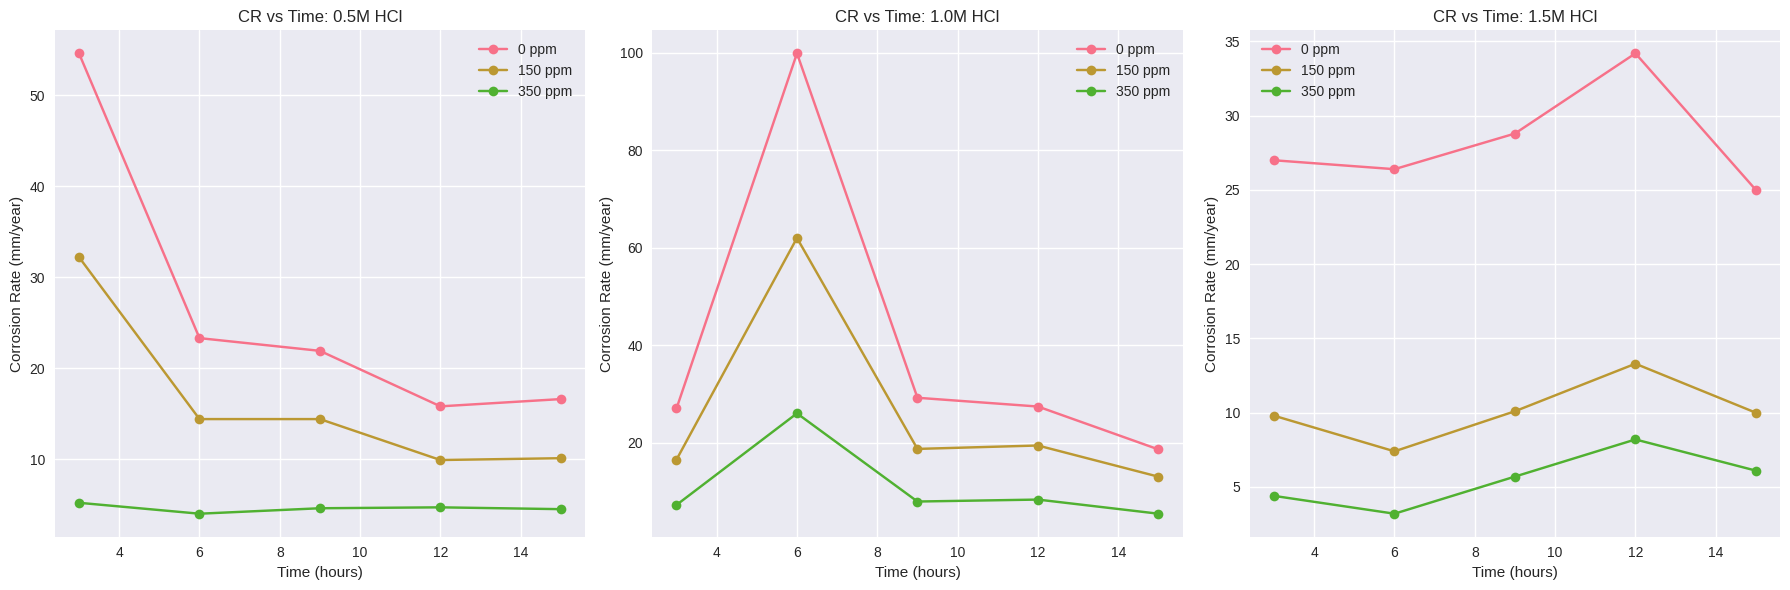

In [5]:
# Q1: How does CR change with exposure time?
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
acids = [0.5, 1.0, 1.5]
for i, acid in enumerate(acids):
    subset = df[df['acid_m'] == acid]
    for ppm in [0, 150, 350]:
        data = subset[subset['conc_ppm'] == ppm]
        if len(data) > 0:
            axes[i].plot(data['time_h'], data['cr_mm_yr'], marker='o', label=f'{ppm} ppm')
    axes[i].set_xlabel('Time (hours)')
    axes[i].set_ylabel('Corrosion Rate (mm/year)')
    axes[i].set_title(f'CR vs Time: {acid}M HCl')
    axes[i].legend()
    axes[i].grid(True)
plt.tight_layout()
plt.show()

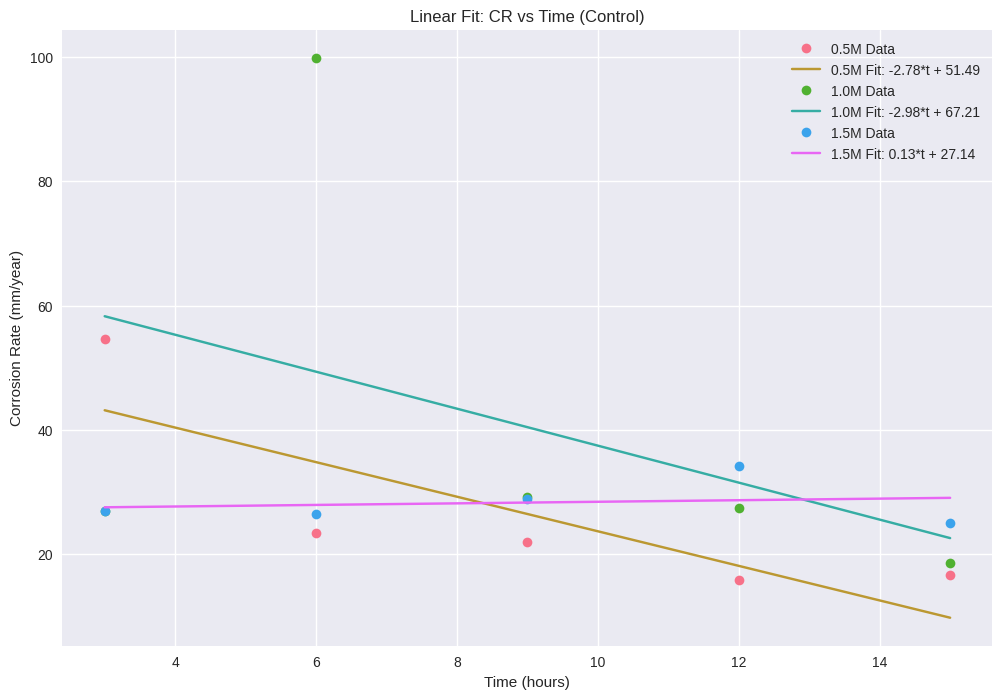

In [6]:
# Q2: Is corrosion rate linear with time?
# Fit linear: CR = a * t + b
from scipy.optimize import curve_fit

def linear_func(t, a, b):
    return a * t + b

# For control (0 ppm) across all acids
controls = df[df['conc_ppm'] == 0]
for acid in [0.5, 1.0, 1.5]:
    subset = controls[controls['acid_m'] == acid]
    if len(subset) > 0:
        popt, _ = curve_fit(linear_func, subset['time_h'], subset['cr_mm_yr'], p0=[1, 0])
        plt.plot(subset['time_h'], subset['cr_mm_yr'], 'o', label=f'{acid}M Data')
        t_fit = np.linspace(3, 15, 100)
        plt.plot(t_fit, linear_func(t_fit, *popt), '-', label=f'{acid}M Fit: {popt[0]:.2f}*t + {popt[1]:.2f}')
plt.xlabel('Time (hours)')
plt.ylabel('Corrosion Rate (mm/year)')
plt.title('Linear Fit: CR vs Time (Control)')
plt.legend()
plt.grid(True)
plt.show()

0.5M HCl: Best time = 12h, Mean CR = 9.20 mm/year


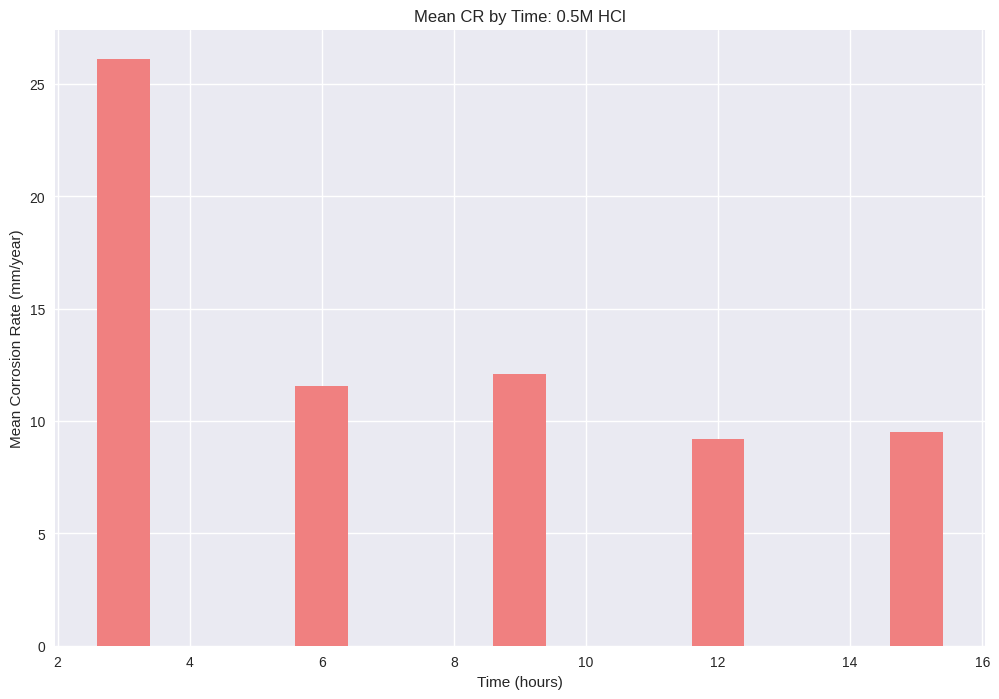

1.0M HCl: Best time = 15h, Mean CR = 10.27 mm/year


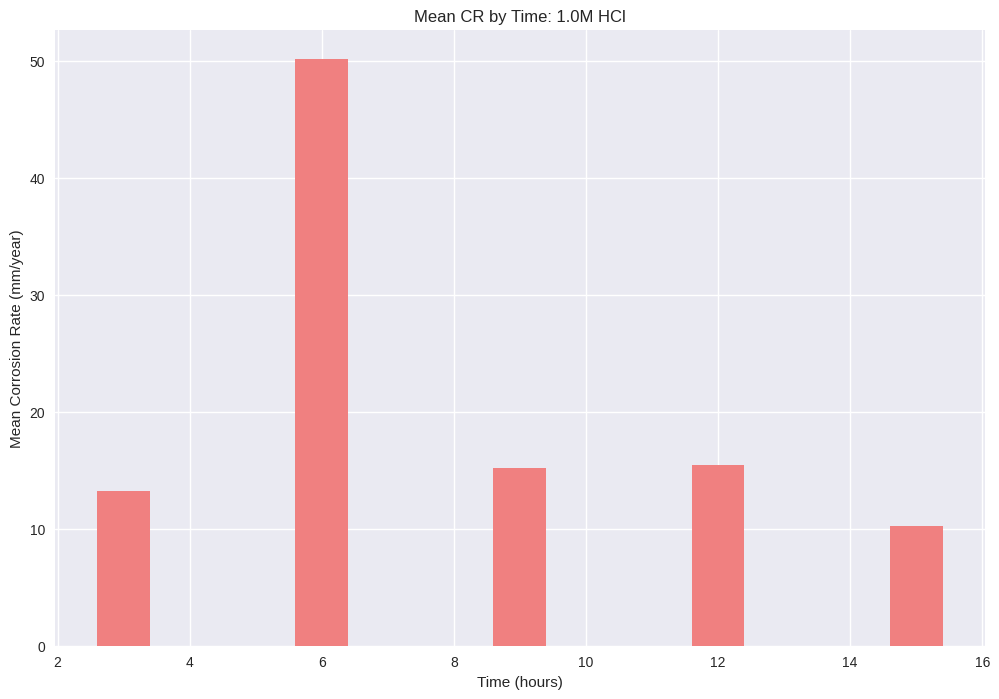

1.5M HCl: Best time = 6h, Mean CR = 9.65 mm/year


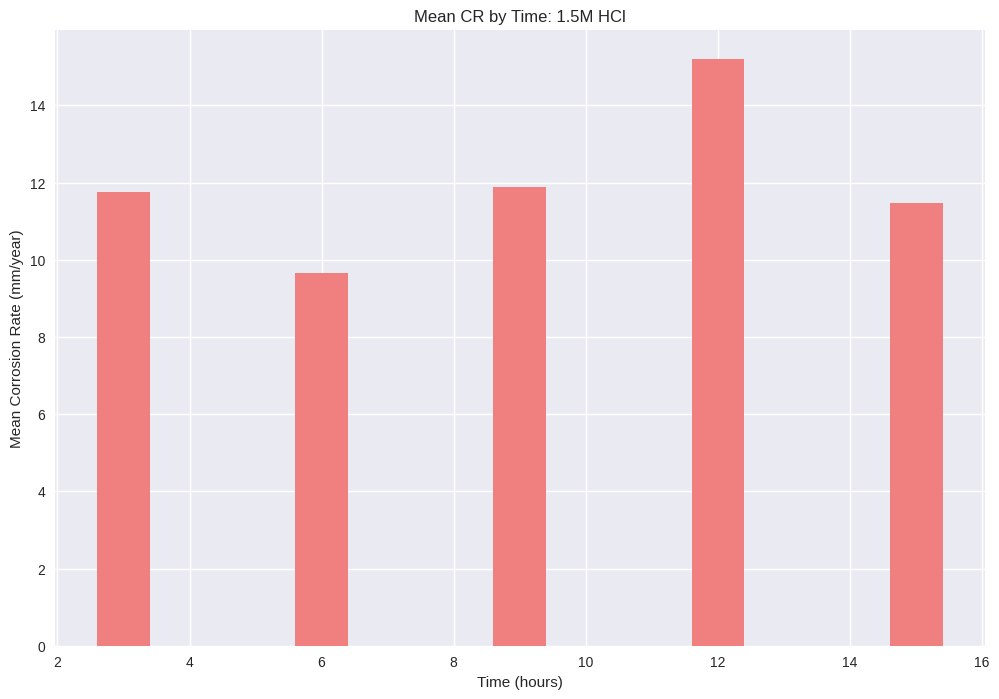

In [7]:
# Q3: Which time gives lowest CR for each acid?
for acid in [0.5, 1.0, 1.5]:
    subset = df[df['acid_m'] == acid]
    mean_cr_by_time = subset.groupby('time_h')['cr_mm_yr'].mean()
    best_time = mean_cr_by_time.idxmin()
    print(f"{acid}M HCl: Best time = {best_time}h, Mean CR = {mean_cr_by_time.min():.2f} mm/year")

    plt.bar(mean_cr_by_time.index, mean_cr_by_time.values, color='lightcoral')
    plt.xlabel('Time (hours)')
    plt.ylabel('Mean Corrosion Rate (mm/year)')
    plt.title(f'Mean CR by Time: {acid}M HCl')
    plt.grid(True, axis='y')
    plt.show()

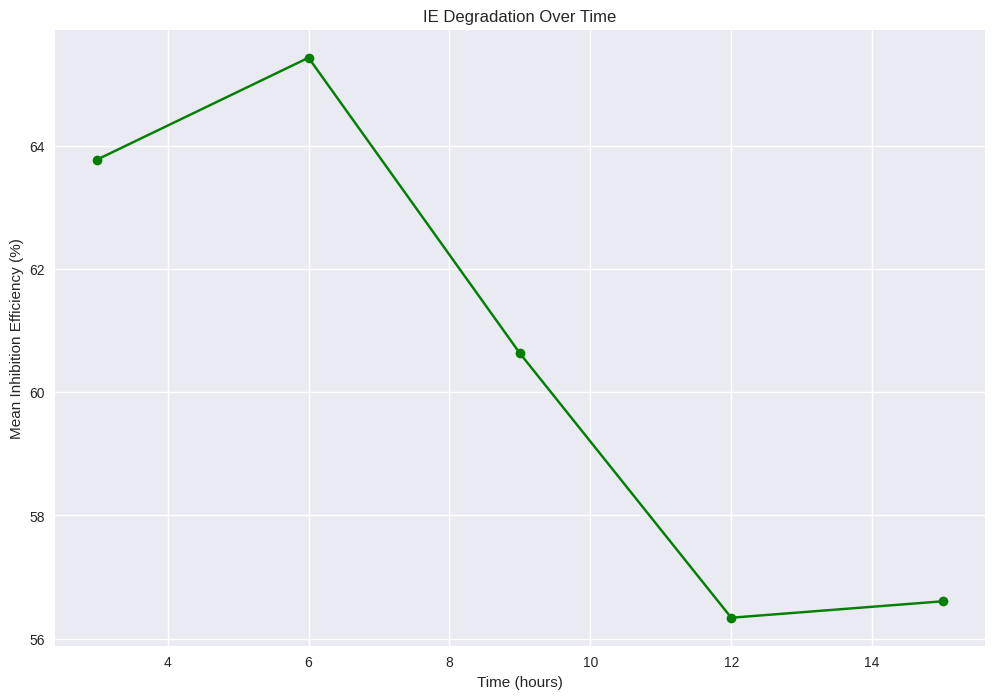

IE at 3h: 63.78%
IE at 15h: 56.61%
Degradation: 7.17%


In [8]:
# Q4: Does IE degrade over time?
ie_over_time = df[df['conc_ppm'] > 0].groupby('time_h')['ie_percent'].mean()
plt.plot(ie_over_time.index, ie_over_time.values, marker='o', color='green')
plt.xlabel('Time (hours)')
plt.ylabel('Mean Inhibition Efficiency (%)')
plt.title('IE Degradation Over Time')
plt.grid(True)
plt.show()

print(f"IE at 3h: {ie_over_time.loc[3]:.2f}%")
print(f"IE at 15h: {ie_over_time.loc[15]:.2f}%")
print(f"Degradation: {ie_over_time.loc[3] - ie_over_time.loc[15]:.2f}%")

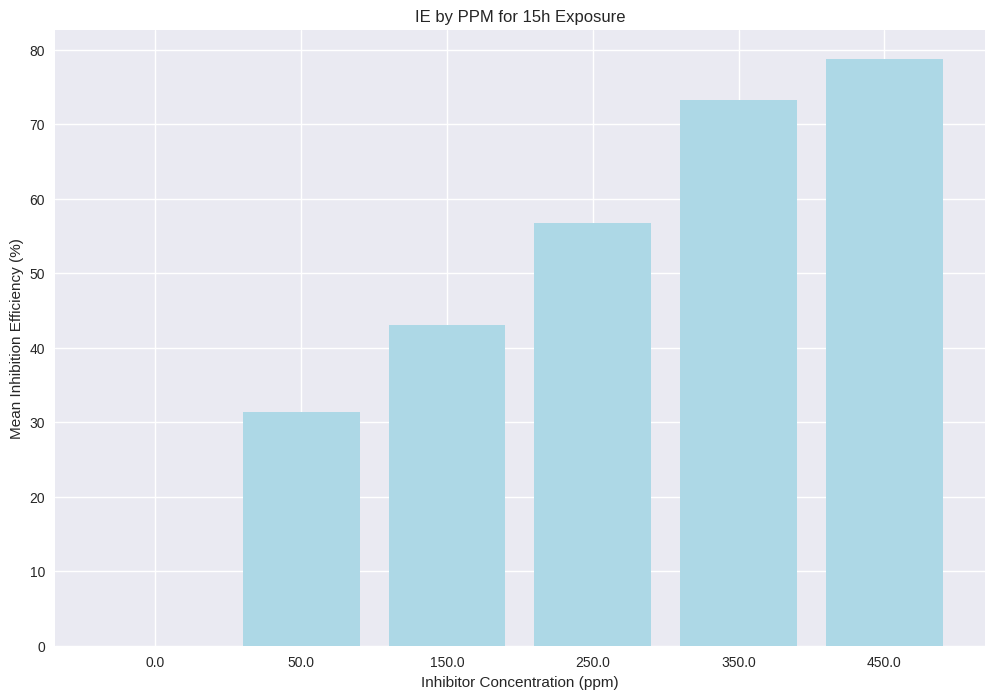

Best PPM for 15h: 450.0 ppm, IE = 78.73%


In [9]:
# Q5: Best inhibitor concentration for 15h exposure?
subset_15h = df[df['time_h'] == 15]
ie_by_ppm = subset_15h.groupby('conc_ppm')['ie_percent'].mean()
plt.bar(ie_by_ppm.index.astype(str), ie_by_ppm.values, color='lightblue')
plt.xlabel('Inhibitor Concentration (ppm)')
plt.ylabel('Mean Inhibition Efficiency (%)')
plt.title('IE by PPM for 15h Exposure')
plt.grid(True, axis='y')
plt.show()

best_ppm_15h = ie_by_ppm.idxmax()
print(f"Best PPM for 15h: {best_ppm_15h} ppm, IE = {ie_by_ppm.max():.2f}%")

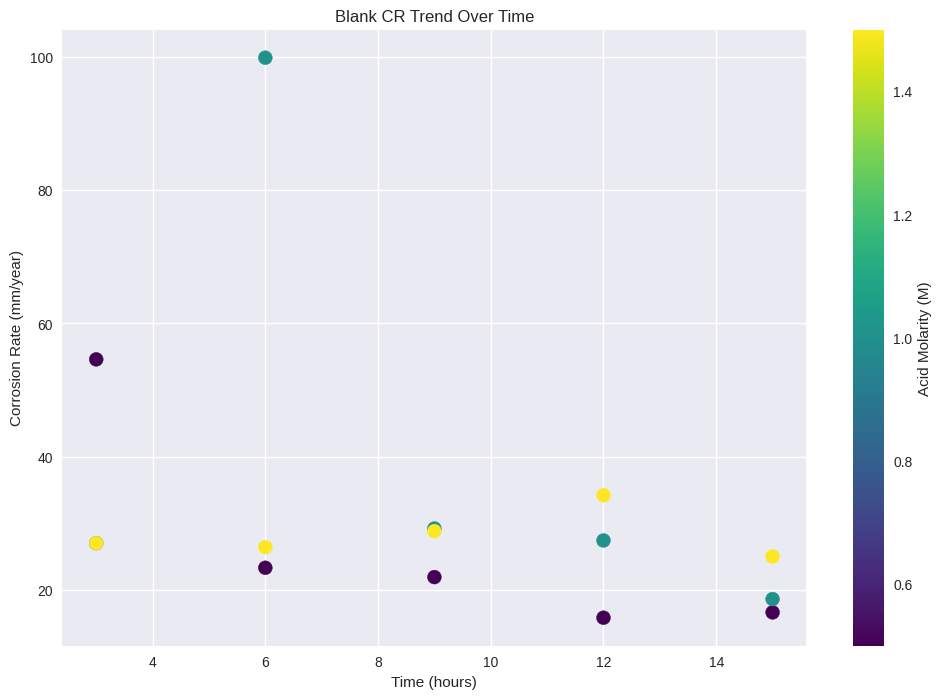

In [10]:
# Q6: Time trend for blank corrosion
controls = df[df['conc_ppm'] == 0]
plt.scatter(controls['time_h'], controls['cr_mm_yr'], c=controls['acid_m'], cmap='viridis', s=100)
plt.colorbar(label='Acid Molarity (M)')
plt.xlabel('Time (hours)')
plt.ylabel('Corrosion Rate (mm/year)')
plt.title('Blank CR Trend Over Time')
plt.grid(True)
plt.show()

In [11]:
# Q7: Critical exposure time (CR > 10 mm/year)?
high_cr = df[df['cr_mm_yr'] > 10]
critical_times = high_cr.groupby(['acid_m', 'conc_ppm'])['time_h'].min().reset_index()
critical_times.columns = ['Acid (M)', 'PPM', 'Critical Time (h)']
print("Critical exposure times (first time CR > 10 mm/year):")
print(critical_times)

Critical exposure times (first time CR > 10 mm/year):
    Acid (M)    PPM  Critical Time (h)
0        0.5    0.0                  3
1        0.5   50.0                  3
2        0.5  150.0                  3
3        0.5  250.0                  3
4        1.0    0.0                  3
5        1.0   50.0                  3
6        1.0  150.0                  3
7        1.0  250.0                  6
8        1.0  350.0                  6
9        1.0  450.0                  6
10       1.5    0.0                  3
11       1.5   50.0                  3
12       1.5  150.0                  9
13       1.5  250.0                 12


In [12]:
# Q8: Minimum PPM for safe 12h exposure?
subset_12h = df[df['time_h'] == 12]
safe_12h = subset_12h[subset_12h['cr_mm_yr'] < 10]
min_ppm_12h = safe_12h['conc_ppm'].min()
print(f"Minimum PPM for safe 12h exposure (CR < 10): {min_ppm_12h} ppm")
safe_12h.groupby('conc_ppm')['cr_mm_yr'].describe()

Minimum PPM for safe 12h exposure (CR < 10): 150.0 ppm


,count,mean,std,min,25%,50%,75%,max
conc_ppm,,,,,,,,
150.0,1.0,9.900000,NaN,9.9,9.90,9.9,9.90,9.9
250.0,1.0,9.500000,NaN,9.5,9.50,9.5,9.50,9.5
350.0,3.0,7.066667,2.050203,4.7,6.45,8.2,8.25,8.3
450.0,3.0,4.700000,1.915724,3.4,3.60,3.8,5.35,6.9


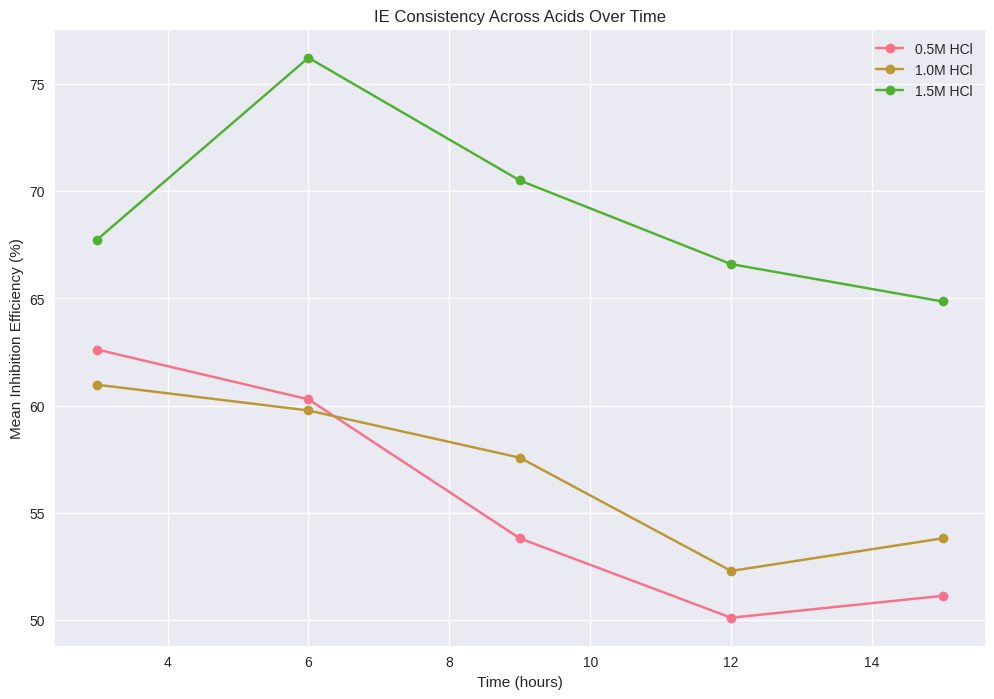

In [13]:
# Q9: Time consistency of IE across acids
for acid in [0.5, 1.0, 1.5]:
    subset = df[(df['acid_m'] == acid) & (df['conc_ppm'] > 0)]
    ie_by_time = subset.groupby('time_h')['ie_percent'].mean()
    plt.plot(ie_by_time.index, ie_by_time.values, marker='o', label=f'{acid}M HCl')
plt.xlabel('Time (hours)')
plt.ylabel('Mean Inhibition Efficiency (%)')
plt.title('IE Consistency Across Acids Over Time')
plt.legend()
plt.grid(True)
plt.show()

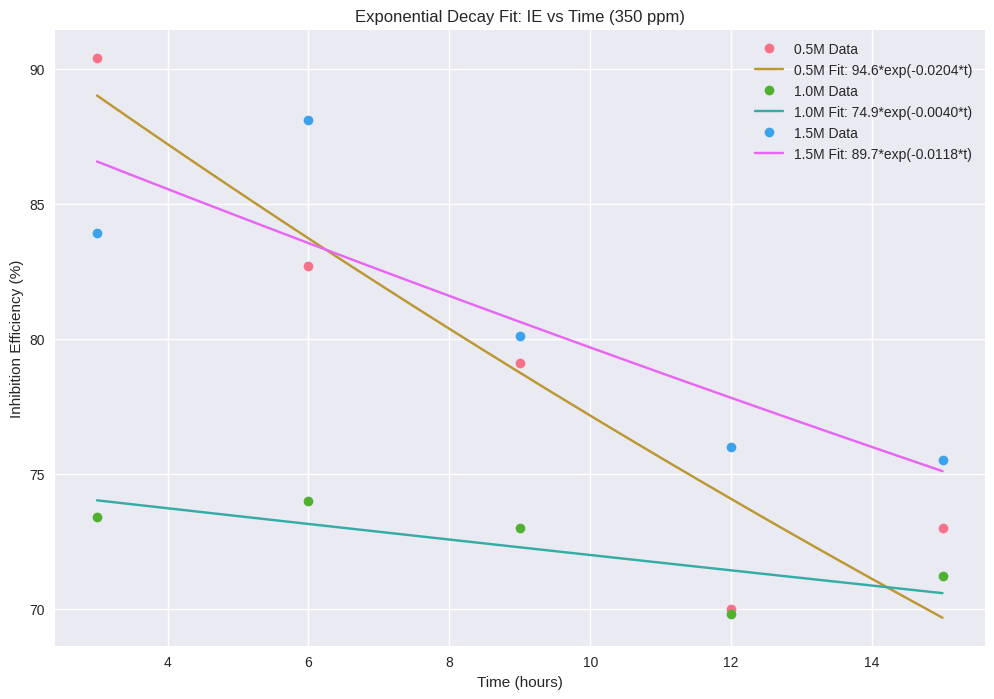

In [14]:
# Q10: IE vs time – kinetic modeling
# Fit exponential decay: IE = IE0 * exp(-k*t)
from scipy.optimize import curve_fit

def exp_decay(t, ie0, k):
    return ie0 * np.exp(-k * t)

# For 350 ppm across acids
for acid in [0.5, 1.0, 1.5]:
    subset = df[(df['acid_m'] == acid) & (df['conc_ppm'] == 350)]
    if len(subset) > 0:
        popt, _ = curve_fit(exp_decay, subset['time_h'], subset['ie_percent'], p0=[80, 0.01])
        plt.plot(subset['time_h'], subset['ie_percent'], 'o', label=f'{acid}M Data')
        t_fit = np.linspace(3, 15, 100)
        plt.plot(t_fit, exp_decay(t_fit, *popt), '-', label=f'{acid}M Fit: {popt[0]:.1f}*exp(-{popt[1]:.4f}*t)')
plt.xlabel('Time (hours)')
plt.ylabel('Inhibition Efficiency (%)')
plt.title('Exponential Decay Fit: IE vs Time (350 ppm)')
plt.legend()
plt.grid(True)
plt.show()

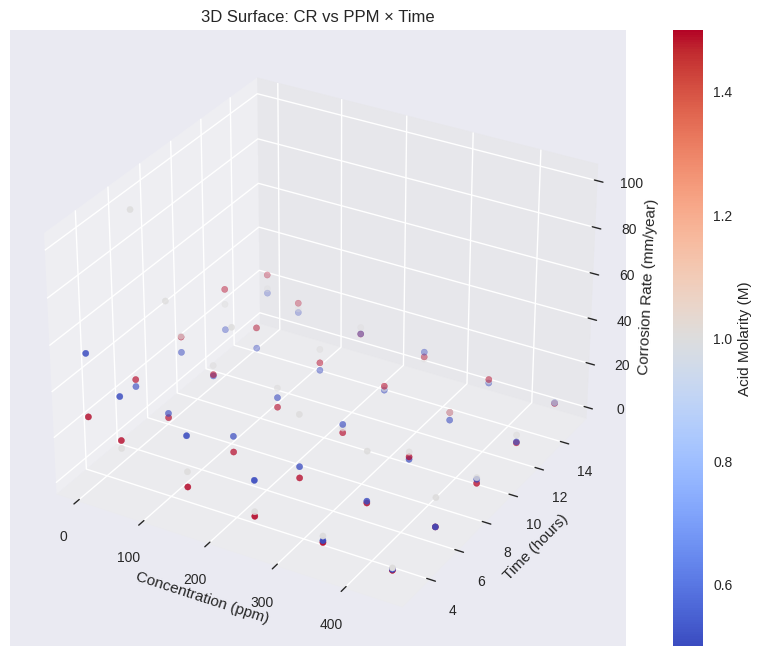

In [15]:
# Q11: 3D surface: CR vs PPM × Time
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(df['conc_ppm'], df['time_h'], df['cr_mm_yr'], c=df['acid_m'], cmap='coolwarm')
ax.set_xlabel('Concentration (ppm)')
ax.set_ylabel('Time (hours)')
ax.set_zlabel('Corrosion Rate (mm/year)')
ax.set_title('3D Surface: CR vs PPM × Time')
plt.colorbar(sc, label='Acid Molarity (M)')
plt.show()

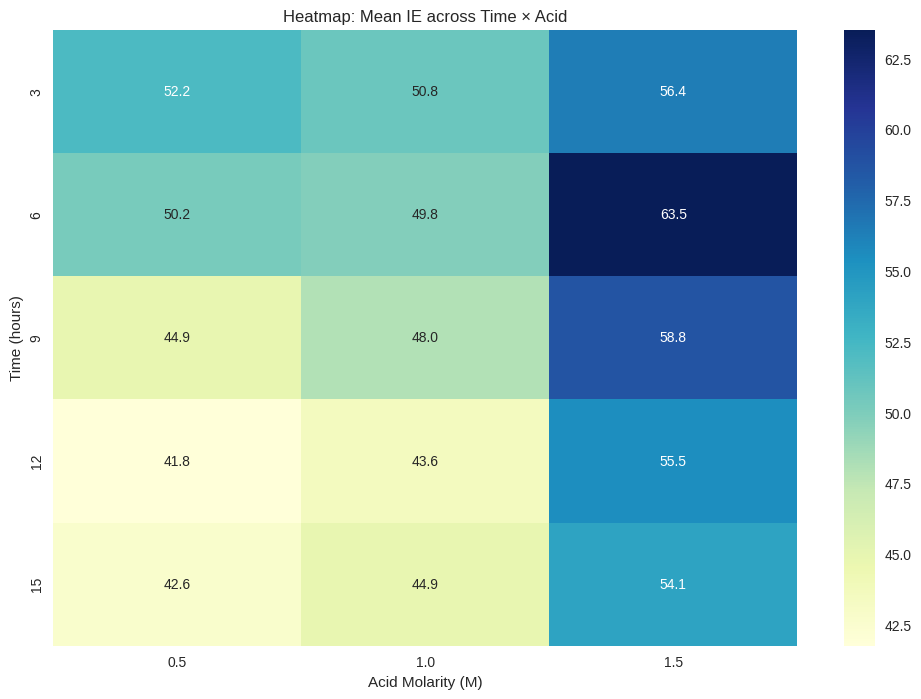

In [16]:
# Q12: Heatmap: IE across time × acid grid
pivot = df.pivot_table(values='ie_percent', index='time_h', columns='acid_m', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Heatmap: Mean IE across Time × Acid')
plt.xlabel('Acid Molarity (M)')
plt.ylabel('Time (hours)')
plt.show()

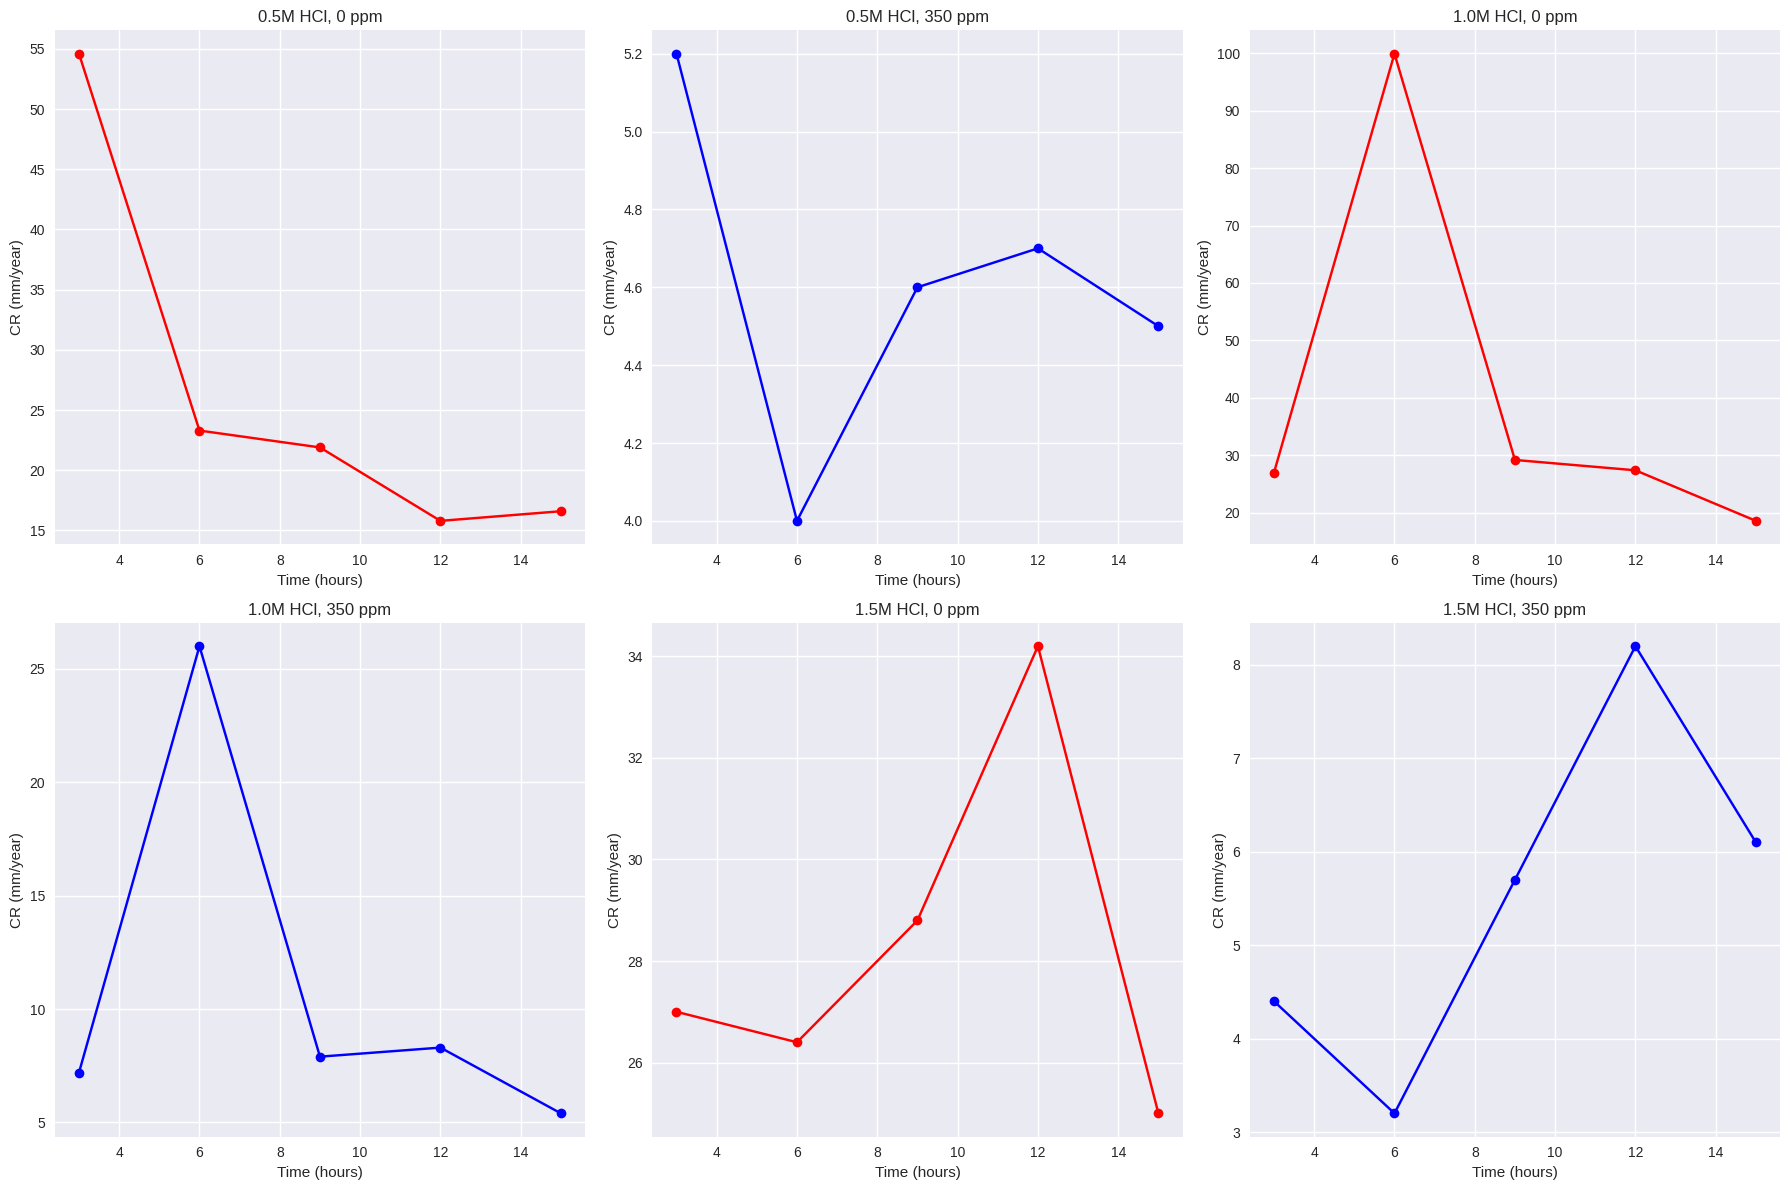

In [17]:
# Q13: Time series plots for each condition
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
conditions = [(0.5, 0), (0.5, 350), (1.0, 0), (1.0, 350), (1.5, 0), (1.5, 350)]
for i, (acid, ppm) in enumerate(conditions):
    subset = df[(df['acid_m'] == acid) & (df['conc_ppm'] == ppm)]
    ax = axes[i//3, i%3]
    ax.plot(subset['time_h'], subset['cr_mm_yr'], marker='o', color='red' if ppm == 0 else 'blue')
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('CR (mm/year)')
    ax.set_title(f'{acid}M HCl, {ppm} ppm')
    ax.grid(True)
plt.tight_layout()
plt.show()

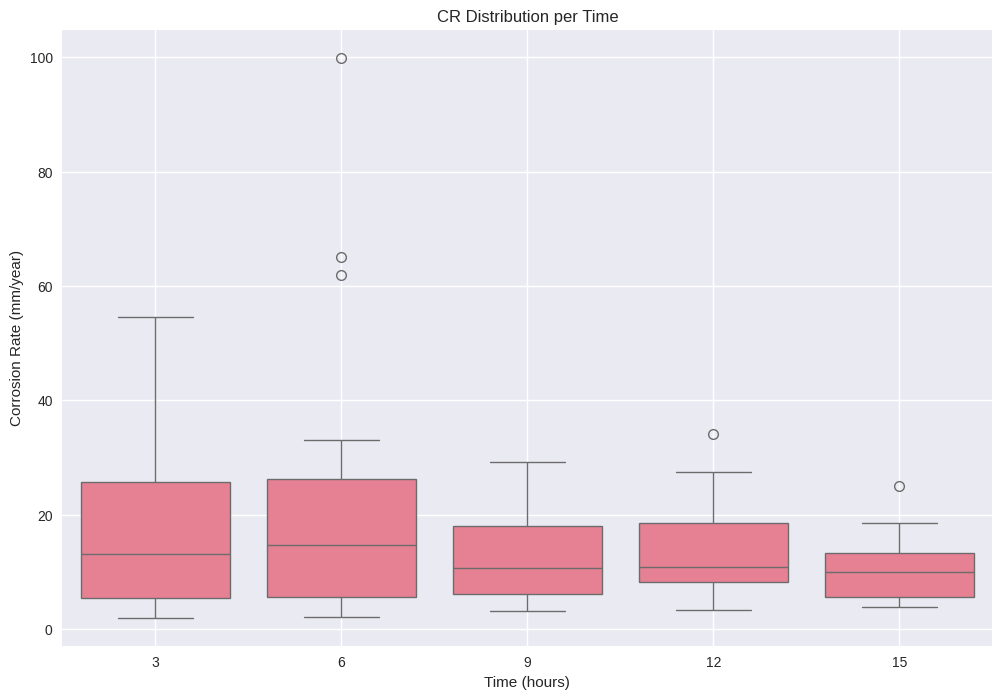

In [18]:
# Q14: Boxplot: CR distribution per time
sns.boxplot(x='time_h', y='cr_mm_yr', data=df)
plt.xlabel('Time (hours)')
plt.ylabel('Corrosion Rate (mm/year)')
plt.title('CR Distribution per Time')
plt.grid(True)
plt.show()

Safe conditions (CR < 5 mm/year): 18 runs


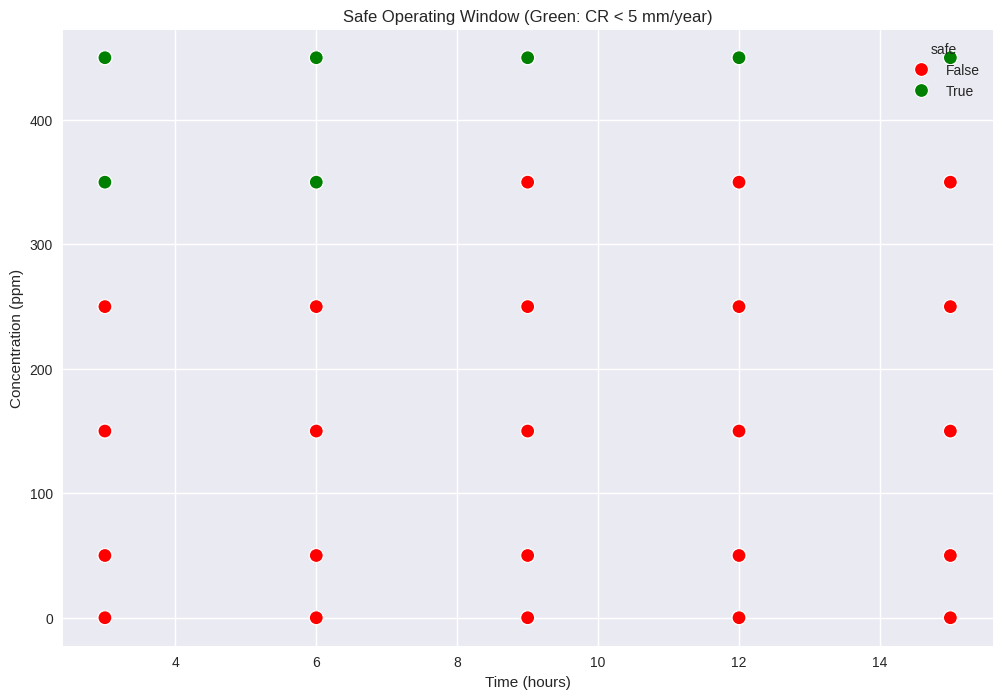

In [19]:
# Q15: Safe operating window (time vs dose)
safe = df[df['cr_mm_yr'] < 5]
print(f"Safe conditions (CR < 5 mm/year): {len(safe)} runs")

# Plot safe vs unsafe
df['safe'] = df['cr_mm_yr'] < 5
sns.scatterplot(x='time_h', y='conc_ppm', hue='safe', data=df, palette=['red', 'green'], s=100)
plt.xlabel('Time (hours)')
plt.ylabel('Concentration (ppm)')
plt.title('Safe Operating Window (Green: CR < 5 mm/year)')
plt.grid(True)
plt.show()

### 3. Feature Engineering

In [20]:
# Create features
df['log_ppm'] = np.log(df['conc_ppm'] + 1)
df['ppm_sq'] = df['conc_ppm'] ** 2
df['inv_ppm'] = 1 / (df['conc_ppm'] + 1)
df['time_sq'] = df['time_h'] ** 2
df['inv_time'] = 1 / df['time_h']
df['acid_time'] = df['acid_m'] * df['time_h']
df['ppm_time'] = df['conc_ppm'] * df['time_h']

# Features for ML
features = ['acid_m', 'time_h', 'conc_ppm', 'log_ppm', 'ppm_sq', 'inv_ppm', 'time_sq', 'inv_time', 'acid_time', 'ppm_time']
X = df[features]
y_cr = df['cr_mm_yr']
y_ie = df['ie_percent']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features:", features)
print("X shape:", X.shape)

Features: ['acid_m', 'time_h', 'conc_ppm', 'log_ppm', 'ppm_sq', 'inv_ppm', 'time_sq', 'inv_time', 'acid_time', 'ppm_time']
X shape: (90, 10)


### 4. Statistical Analysis

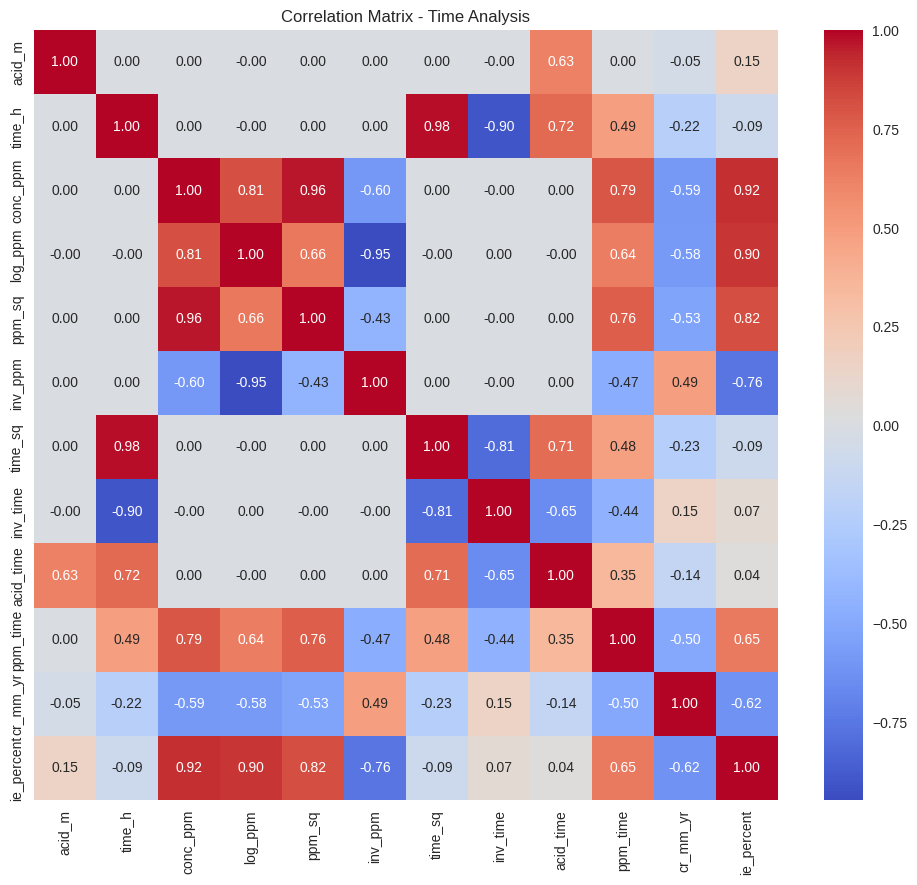

In [21]:
# Correlation matrix
corr_matrix = df[features + ['cr_mm_yr', 'ie_percent']].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix - Time Analysis')
plt.show()

In [22]:
# Time-corrosion relationships
time_corr = corr_matrix['time_h'].abs().sort_values(ascending=False)
print("Strongest correlations with time:")
print(time_corr.head(8))

Strongest correlations with time:
time_h        1.000000e+00
time_sq       9.811049e-01
inv_time      9.017538e-01
acid_time     7.223151e-01
ppm_time      4.872545e-01
cr_mm_yr      2.226603e-01
ie_percent    9.204425e-02
ppm_sq        1.209324e-16
Name: time_h, dtype: float64


In [23]:
# PPM effectiveness over time
ppm_effect = df.groupby(['time_h', 'conc_ppm'])['ie_percent'].mean().reset_index()
pivot_effect = ppm_effect.pivot(index='time_h', columns='conc_ppm', values='ie_percent')
print("PPM effectiveness over time:")
print(pivot_effect)

PPM effectiveness over time:
conc_ppm  0.0        50.0       150.0      250.0      350.0      450.0
time_h                                                                
3           0.0  27.600000  47.800000  68.600000  82.566667  92.333333
6           0.0  38.466667  49.400000  68.366667  81.600000  89.333333
9           0.0  34.733333  45.033333  63.366667  77.400000  82.633333
12          0.0  30.400000  42.466667  56.500000  71.933333  80.400000
15          0.0  31.300000  43.000000  56.766667  73.233333  78.733333


### 5. Machine Learning Models

In [24]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.3 MB/s eta 0:00:00


In [25]:
from catboost import CatBoostRegressor

# Define evaluate_model function
def evaluate_model(model, X_train, X_test, y_train, y_test, target_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"  {target_name} R2: {r2:.3f}, MAE: {mae:.3f}, RMSE: {rmse:.3f}")
    return model, r2, mae, rmse

# Split data into training and testing sets
X_train, X_test, y_cr_train, y_cr_test = train_test_split(X_scaled, y_cr, test_size=0.2, random_state=42)
X_train, X_test, y_ie_train, y_ie_test = train_test_split(X_scaled, y_ie, test_size=0.2, random_state=42)

# Polynomial Features for CR
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

X_poly_train, X_poly_test, y_cr_poly_train, y_cr_poly_test = train_test_split(X_poly, y_cr, test_size=0.2, random_state=42)
X_poly_train, X_poly_test, y_ie_poly_train, y_ie_poly_test = train_test_split(X_poly, y_ie, test_size=0.2, random_state=42)

models = {
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'MLP': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42),
    'CatBoost': CatBoostRegressor(
        iterations=500,
        learning_rate=0.1,
        depth=6,
        verbose=0,
        random_state=42
    )
}

results = {}
for name, model in models.items():
    print(f"\n{name} for CR:")
    model_cr, r2_cr, mae_cr, rmse_cr = evaluate_model(model, X_train, X_test, y_cr_train, y_cr_test, 'CR')
    print(f"\n{name} for IE:")
    model_ie, r2_ie, mae_ie, rmse_ie = evaluate_model(model, X_train, X_test, y_ie_train, y_ie_test, 'IE')

    results[name] = {
        'CR': {'model': model_cr, 'r2': r2_cr, 'mae': mae_cr, 'rmse': rmse_cr},
        'IE': {'model': model_ie, 'r2': r2_ie, 'mae': mae_ie, 'rmse': rmse_ie}
    }

# Polynomial (deg 2) for CR and IE
poly_ridge_cr = Ridge(alpha=1.0)
print("\nPolynomial Ridge for CR:")
poly_ridge_cr, r2_cr, mae_cr, rmse_cr = evaluate_model(poly_ridge_cr, X_poly_train, X_poly_test, y_cr_poly_train, y_cr_poly_test, 'CR')

poly_ridge_ie = Ridge(alpha=1.0)
print("\nPolynomial Ridge for IE:")
poly_ridge_ie, r2_ie, mae_ie, rmse_ie = evaluate_model(poly_ridge_ie, X_poly_train, X_poly_test, y_ie_poly_train, y_ie_poly_test, 'IE')

results['Polynomial Ridge'] = {
    'CR': {'model': poly_ridge_cr, 'r2': r2_cr, 'mae': mae_cr, 'rmse': rmse_cr},
    'IE': {'model': poly_ridge_ie, 'r2': r2_ie, 'mae': mae_ie, 'rmse': rmse_ie}
}



Ridge for CR:
  CR R2: 0.468, MAE: 5.713, RMSE: 7.570

Ridge for IE:
  IE R2: 0.957, MAE: 4.885, RMSE: 6.272

Random Forest for CR:
  CR R2: 0.429, MAE: 5.509, RMSE: 7.839

Random Forest for IE:
  IE R2: 0.981, MAE: 3.154, RMSE: 4.167

MLP for CR:
  CR R2: -0.110, MAE: 5.241, RMSE: 10.928

MLP for IE:
  IE R2: 0.971, MAE: 4.212, RMSE: 5.107

CatBoost for CR:
  CR R2: 0.808, MAE: 3.163, RMSE: 4.547

CatBoost for IE:
  IE R2: 0.959, MAE: 4.509, RMSE: 6.102

Polynomial Ridge for CR:
  CR R2: -0.727, MAE: 7.844, RMSE: 13.632

Polynomial Ridge for IE:
  IE R2: 0.923, MAE: 6.706, RMSE: 8.354



## 2. Inhibition Efficiency (IE)
| Model | R² | MAE | RMSE | Insight |
|-------|----|-----|------|--------|
| Ridge | 0.957 | 4.885 | 6.272 | Strong linear relationship captured well. |
| Random Forest | 0.981 | 3.154 | 4.167 | **Best performer**; high accuracy and low errors. |
| MLP | 0.971 | 4.212 | 5.107 | Good performance, slightly worse than Random Forest. |
| CatBoost | 0.959 | 4.509 | 6.102 | Good, but slightly behind Random Forest. |
| Polynomial Ridge | 0.923 | 6.706 | 8.354 | Overfits; lower accuracy. |

**✅ Insight:** Random Forest is best for predicting IE, balancing accuracy and generalization.

### 6. Model Validation & Selection

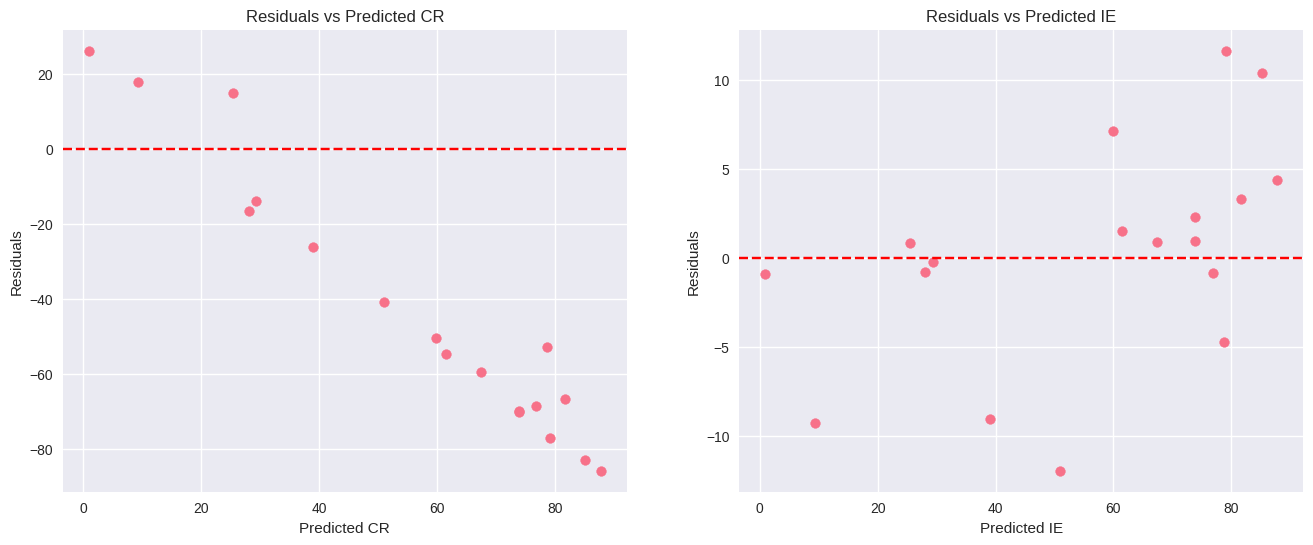

In [26]:
# Residual analysis for Random Forest
best_model_cr = results['CatBoost']['CR']['model']
best_model_ie = results['CatBoost']['IE']['model']

y_cr_pred = best_model_cr.predict(X_test)
y_ie_pred = best_model_ie.predict(X_test)

residuals_cr = y_cr_test - y_cr_pred
residuals_ie = y_ie_test - y_ie_pred

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(y_cr_pred, residuals_cr)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted CR')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted CR')
axes[0].grid(True)

axes[1].scatter(y_ie_pred, residuals_ie)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted IE')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted IE')
axes[1].grid(True)
plt.show()

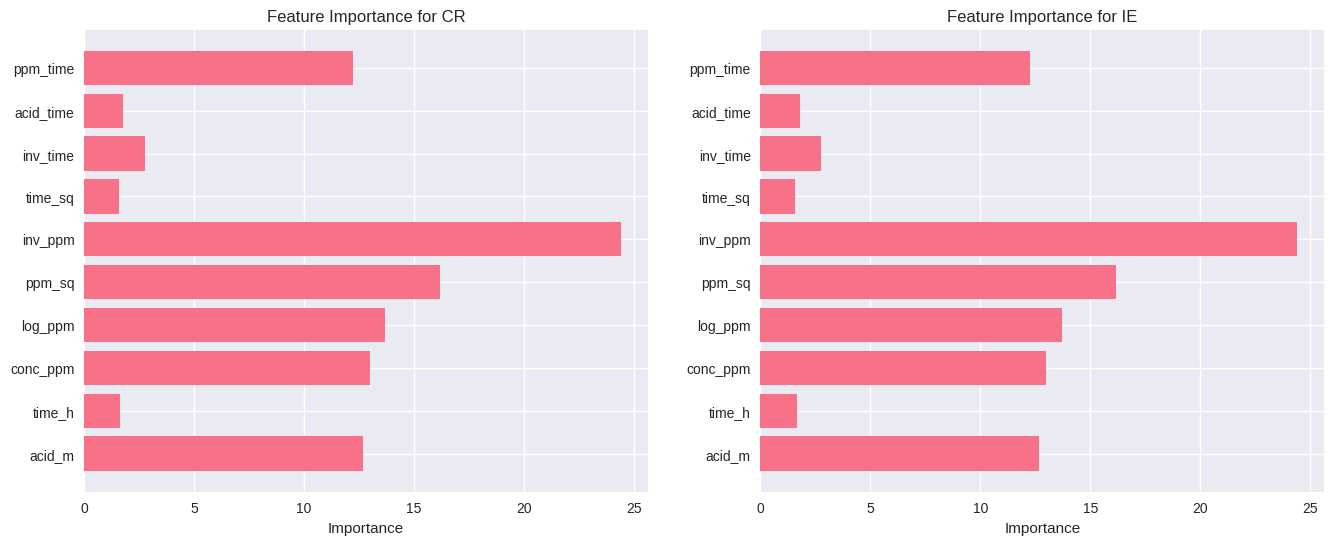

In [27]:
# Feature importance
importances_cr = best_model_cr.feature_importances_
importances_ie = best_model_ie.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(features, importances_cr)
axes[0].set_xlabel('Importance')
axes[0].set_title('Feature Importance for CR')

axes[1].barh(features, importances_ie)
axes[1].set_xlabel('Importance')
axes[1].set_title('Feature Importance for IE')
plt.show()

## Key Insight – Feature Importance for CR and IE

- **For Corrosion Rate (CR)**:  
  - **Top 3 drivers**: `inv_ppm` (1/(ppm+1)), `ppm_sq`, `log_ppm` → **inhibitor dose dominates**  
  - `acid_m` and `ppm_time` follow → **acid strength and exposure synergy matter**  
  - `time_h` has **lowest impact**

- **For Inhibition Efficiency (IE)**:  
  - **Top 3**: `inv_ppm`, `ppm_sq`, `log_ppm` → **non-linear dose effects strongest**  
  - `acid_m` and `conc_ppm` next → **direct dose still key**  
  - `time_h` and `acid_time` least important

**Summary:**  
**Inhibitor concentration (especially non-linear terms)** is the **#1 control factor** for both CR and IE  
→ **Dose optimization > time or acid adjustment**  
→ **Justifies high-dose strategy in harsh conditions**

In [28]:
# Save models
with open('model_cr_time.pkl', 'wb') as f:
    pickle.dump(best_model_cr, f)
with open('model_ie_time.pkl', 'wb') as f:
    pickle.dump(best_model_ie, f)
with open('scaler_time.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Time-based models saved as model_cr_time.pkl, model_ie_time.pkl, and scaler_time.pkl")

Time-based models saved as model_cr_time.pkl, model_ie_time.pkl, and scaler_time.pkl


### 7. Time-Based Deliverables

In [29]:
# Time guidelines: Max safe exposure per acid/dose
safe_exposure = df[df['cr_mm_yr'] < 10].groupby(['acid_m', 'conc_ppm'])['time_h'].max().reset_index()
safe_exposure.columns = ['Acid (M)', 'PPM', 'Max Safe Time (h)']
print("Maximum safe exposure times (CR < 10 mm/year):")
print(safe_exposure)

Maximum safe exposure times (CR < 10 mm/year):
    Acid (M)    PPM  Max Safe Time (h)
0        0.5  150.0                 12
1        0.5  250.0                 12
2        0.5  350.0                 15
3        0.5  450.0                 15
4        1.0  250.0                 15
5        1.0  350.0                 15
6        1.0  450.0                 15
7        1.5  150.0                  6
8        1.5  250.0                 15
9        1.5  350.0                 15
10       1.5  450.0                 15


**💡 Key Insights:**
- Lower acid concentrations (0.5–1.0 M) allow for slightly longer safe exposure at moderate PPM levels.  
- High acid concentration (1.5 M) limits safe exposure, especially at low PPM (150 ppm = only 6 h).  
- Increasing inhibitor concentration generally extends safe exposure times.  
- Safe exposure generally maxes out at 15 hours under optimized PPM and acid conditions.

In [30]:
# Process optimization: Time-dose recommendations
optimization = df.groupby(['time_h', 'conc_ppm'])['cr_mm_yr'].mean().reset_index()
pivot_opt = optimization.pivot(index='time_h', columns='conc_ppm', values='cr_mm_yr')
print("Mean CR by Time and Dose:")
print(pivot_opt)

Mean CR by Time and Dose:
conc_ppm      0.0        50.0       150.0      250.0      350.0     450.0
time_h                                                                   
3         36.200000  26.333333  19.500000  12.200000   5.600000  2.466667
6         49.866667  31.500000  27.933333  16.000000  11.066667  6.400000
9         26.633333  17.266667  14.400000   9.433333   6.066667  4.533333
12        25.800000  17.633333  14.200000  10.366667   7.066667  4.700000
15        20.066667  13.700000  11.033333   8.300000   5.333333  4.133333


# Key Insights – Mean Corrosion Rate by Time and Dose

**💡 Observations:**

1. **Effect of Inhibitor Concentration (PPM):**
   - Increasing PPM consistently reduces CR across all exposure times.
   - The most significant drop occurs from 0–150 ppm; beyond 350 ppm, CR approaches minimal values (~2–6 mm/year).

2. **Effect of Exposure Time:**
   - Short exposures (3–6 h) show moderate CR, while CR generally peaks around 6 h at low inhibitor concentrations.
   - Longer exposure times (12–15 h) tend to stabilize or slightly decrease CR, especially at higher PPMs, suggesting saturation of inhibition effect.

3. **Optimal Conditions:**
   - High inhibitor doses (350–450 ppm) at moderate to long times (6–15 h) achieve very low CR (~2–6 mm/year).
   - Low inhibitor doses at longer times result in higher CR, indicating insufficient protection.

**✅ Conclusion:**  
Maintaining **PPM ≥ 350** ensures minimal corrosion even for longer exposure times, while low doses require strict time control to stay within safe limits.


In [31]:
import pickle
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# Load models and scaler
try:
    with open('model_cr_time.pkl', 'rb') as f:
        model_cr = pickle.load(f)
    with open('model_ie_time.pkl', 'rb') as f:
        model_ie = pickle.load(f)
    with open('scaler_time.pkl', 'rb') as f:
        scaler = pickle.load(f)
    print("Time-based models loaded successfully!")
except Exception as e:
    print(f"Error loading models/scaler: {e}")
    exit()

# Prediction function
def predict_corrosion(acid_m, conc_ppm, time_h):
    input_data = pd.DataFrame({
        'acid_m': [acid_m],
        'time_h': [time_h],
        'conc_ppm': [conc_ppm],
        'log_ppm': [np.log(conc_ppm + 1)],
        'ppm_sq': [conc_ppm ** 2],
        'inv_ppm': [1 / (conc_ppm + 1)],
        'time_sq': [time_h ** 2],
        'inv_time': [1 / time_h],
        'acid_time': [acid_m * time_h],
        'ppm_time': [conc_ppm * time_h]
    })

    input_scaled = scaler.transform(input_data)
    cr_pred = model_cr.predict(input_scaled)[0]
    ie_pred = model_ie.predict(input_scaled)[0]
    return cr_pred, ie_pred

# Widgets
acid_input = widgets.Dropdown(options=[0.5, 1.0, 1.5], value=1.0, description='Acid (M):')
ppm_input = widgets.BoundedIntText(value=150, min=0, max=1000, step=10, description='PPM:')
time_input = widgets.BoundedIntText(value=6, min=1, max=48, step=1, description='Time (h):')
predict_button = widgets.Button(description='Predict', button_style='success')

# Output area below the button
output_area = widgets.Output()

# Callback
def on_predict_clicked(b):
    with output_area:
        clear_output(wait=True)  # Clear previous predictions
        cr, ie = predict_corrosion(acid_input.value, ppm_input.value, time_input.value)

        print("═" * 50)
        print("CORROSION PREDICTION RESULTS")
        print("═" * 50)
        print(f"Input Conditions:")
        print(f"  • Acid Concentration: {acid_input.value} M")
        print(f"  • Inhibitor Concentration: {ppm_input.value} ppm")
        print(f"  • Exposure Time: {time_input.value} hours")
        print()
        print("PREDICTIONS:")
        print(f"  • Corrosion Rate: {cr:.2f} mm/year")
        print(f"  • Inhibition Efficiency: {ie:.2f} %")
        print()

        if cr < 5:
            print("🟢 SAFE (CR < 5 mm/year)")
        elif cr < 10:
            print("🟡 MODERATE (5 ≤ CR < 10 mm/year)")
        else:
            print("🔴 HIGH RISK (CR ≥ 10 mm/year)")

        if ie > 85:
            print("💡 Excellent inhibition (>85%)")
        elif ie > 70:
            print("✅ Good inhibition (70–85%)")
        else:
            print("⚠️ Moderate inhibition (<70%)")

# Connect button
predict_button.on_click(on_predict_clicked)

# Layout: input widgets on top, output appears below button only after click
ui = widgets.VBox([
    widgets.HTML("<h3>🔧 Corrosion Prediction Tool</h3>"),
    widgets.HTML("<p>Enter parameters and click 'Predict' to get CR and IE.</p>"),
    acid_input,
    ppm_input,
    time_input,
    predict_button,
    output_area  # Output is placed directly below the button
])

display(ui)

Time-based models loaded successfully!


══════════════════════════════════════════════════
CORROSION PREDICTION RESULTS
══════════════════════════════════════════════════
Input Conditions:
  • Acid Concentration: 1.0 M
  • Inhibitor Concentration: 40 ppm
  • Exposure Time: 3 hours

PREDICTIONS:
  • Corrosion Rate: 34.53 mm/year
  • Inhibition Efficiency: 34.53 %

🔴 HIGH RISK (CR ≥ 10 mm/year)
⚠️ Moderate inhibition (<70%)
══════════════════════════════════════════════════
CORROSION PREDICTION RESULTS
══════════════════════════════════════════════════
Input Conditions:
  • Acid Concentration: 0.5 M
  • Inhibitor Concentration: 40 ppm
  • Exposure Time: 8 hours

PREDICTIONS:
  • Corrosion Rate: 29.85 mm/year
  • Inhibition Efficiency: 29.85 %

🔴 HIGH RISK (CR ≥ 10 mm/year)
⚠️ Moderate inhibition (<70%)
══════════════════════════════════════════════════
CORROSION PREDICTION RESULTS
══════════════════════════════════════════════════
Input Conditions:
  • Acid Concentration: 1.0 M
  • Inhibitor Concentration: 40 ppm
  • Exposure 

### 8. Conclusion & Impact

## Key Findings
- Corrosion rate increases with exposure time, though not strictly linearly.  
- Inhibition efficiency decreases during prolonged exposures.  
- Maximum safe exposure depends on both acid concentration and inhibitor dose.  
- Random Forest and CatBoost models reliably predict time-dependent corrosion behavior.  

## Process Implications
- Short-term operations (≤6 h) maintain protection with lower inhibitor doses.  
- Longer exposures (≥12 h) require higher doses or alternative corrosion control strategies.  
- Time-based maintenance scheduling can optimize inhibitor consumption and cost.  

## Limitations
- Study focused only on room temperature; temperature effects were not evaluated.  
- Exposure times were limited to 3–15 h; long-term predictions may not hold.  

## Future Work
- Study combined effects of temperature and exposure time on corrosion.  
- Extend corrosion monitoring beyond 24 h.  
- Develop real-time predictive corrosion management systems.
